In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

In [2]:
PATHOGENS = ["abaumannii", "calbicans", "campylobacter", "ecoli", "efaecium", 
    "enterobacter", "hpylori", "kpneumoniae", "mtuberculosis", 
    "ngonorrhoeae", "paeruginosa", "pfalciparum", "saureus", 
    "smansoni", "spneumoniae"]

PATH_TO_OUTPUT = "../output"

In [5]:
num_mols_original, num_mols_cleaned = [], []
num_tasks, num_modelable_tasks = [], []
names = []

for pathogen in PATHOGENS:

    # Read data
    # data_pathogen = pd.read_csv(os.path.join(PATH_TO_OUTPUT, pathogen, f"016_{pathogen}_summary.csv"))
    names.append(pathogen)

    # Number of molecules original
    try:
        num_mols_original.append(len(open(os.path.join(PATH_TO_OUTPUT, pathogen, f"011_{pathogen}_original.csv")).readlines()) - 1)
    except:
        num_mols_original.append(0)

    # Number of molecules cleaned
    try:
        num_mols_cleaned.append(len(open(os.path.join(PATH_TO_OUTPUT, pathogen, f"012_{pathogen}_cleaned.csv")).readlines()) - 1)
    except:
        num_mols_cleaned.append(0)

    # Number of tasks
    try:
        num_tasks.append(len(os.listdir(os.path.join(PATH_TO_OUTPUT, pathogen, "013_raw_tasks"))))
    except:
        num_tasks.append(0)

    # Number of selcted tasks
    try:
        num_modelable_tasks.append(len(os.listdir(os.path.join(PATH_TO_OUTPUT, pathogen, "016_tasks"))))
    except:
        num_modelable_tasks.append(0)


num_mols_original = np.array(num_mols_original)
num_mols_cleaned = np.array(num_mols_cleaned)
num_tasks = np.array(num_tasks)
num_modelable_tasks = np.array(num_modelable_tasks)
names = np.array(names)

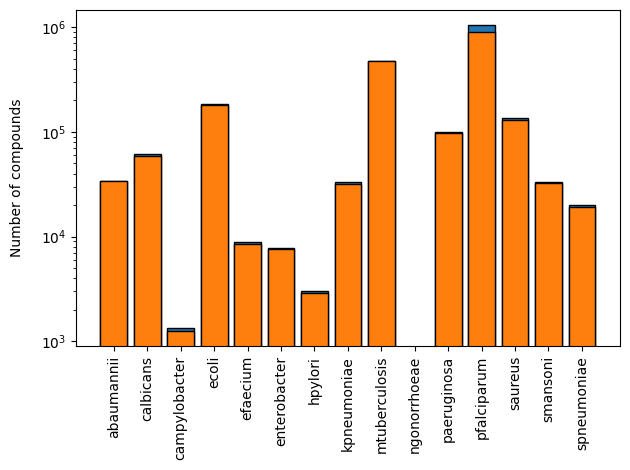

In [19]:
plt.bar([i for i in range(len(names))], num_mols_original, ec='k')
plt.bar([i for i in range(len(names))], num_mols_cleaned, ec='k')
plt.yscale('log')
plt.xticks([i for i in range(len(names))], names, rotation=90)

plt.ylabel("Number of compounds", labelpad=12)
plt.tight_layout()
plt.savefig("../plots/num_compounds.png", dpi=300)
plt.show()